# Individual homework project 1

In [2]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Import data
customers= pd.read_csv('data/data/customers.csv')
transactions = pd.read_csv('data/data/transactions.csv')
web_sessions= pd.read_csv('data/data/web_sessions.csv')
campaign_touchpoints= pd.read_csv('data/data/campaign_touchpoints.csv')

### Exploring Data

In [11]:
#columns in each table

campaign_touchpoints.columns


Index(['customer_id', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date', 'customer_status', 'loyalty_tier', 'campaign_id',
       'last_active_date'],
      dtype='str')

In [13]:
customers.columns

Index(['customer_id', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date', 'customer_status', 'loyalty_tier', 'campaign_id',
       'last_active_date'],
      dtype='str')

In [14]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date', 'is_refunded', 'refund_date',
       'refund_reason'],
      dtype='str')

In [15]:
web_sessions.columns

Index(['session_id', 'customer_id', 'pages_viewed', 'time_on_site',
       'device_type', 'traffic_source', 'session_date', 'converted', 'bounce',
       'cart_additions', 'checkout_started', 'exit_page', 'browser',
       'is_logged_in'],
      dtype='str')

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [95]:
merged= customers[['customer_id', 'country']].merge(
                   transactions[['purchase_value', 'customer_id']],
                   on='customer_id', how='inner'
)

spain=merged[merged['country']=='Spain']
print(spain)

np.mean(spain['purchase_value'])

       customer_id country  purchase_value
54              12   Spain          140.03
55              12   Spain          257.30
56              13   Spain          191.63
57              13   Spain           84.11
58              13   Spain           51.71
...            ...     ...             ...
44979         9995   Spain          208.61
44980         9995   Spain          214.27
44981         9995   Spain          979.26
44988         9997   Spain          143.70
44989         9997   Spain           19.41

[5648 rows x 3 columns]


np.float64(230.95889872521244)

 **Ans** **230.959**

Q2. What is the minimum purchase value for customers from Germany?

In [96]:
Germany=merged[merged['country']=='Germany']
print(Germany)

np.min(Germany['purchase_value'])

       customer_id  country  purchase_value
16               6  Germany           45.95
17               6  Germany           31.42
18               6  Germany          259.36
32               8  Germany          176.24
33               8  Germany          281.06
...            ...      ...             ...
44931         9985  Germany          139.76
44960         9991  Germany           56.10
44961         9991  Germany           78.03
44962         9991  Germany           71.29
44963         9991  Germany          111.30

[5368 rows x 3 columns]


np.float64(10.01)

**Ans** **10.01**

Q3. How much did males spend on buying products in the Sports category?

In [97]:
merged= customers[['customer_id', 'gender']].merge(
                   transactions[['purchase_value', 'product_category', 'customer_id']],
                   on='customer_id', how='inner'
)
Male_sports=merged[(merged['gender']=='Male') & (merged['product_category']=='sports')]
print(Male_sports)

np.sum(Male_sports['purchase_value'])

       customer_id gender  purchase_value product_category
33               8   Male          281.06           sports
34               8   Male          234.15           sports
39               9   Male           56.87           sports
78              17   Male          173.79           sports
79              17   Male          288.04           sports
...            ...    ...             ...              ...
44763         9950   Male           27.83           sports
44812         9961   Male          174.62           sports
44910         9979   Male           32.97           sports
44926         9983   Male          190.82           sports
44982         9996   Male          117.89           sports

[2542 rows x 4 columns]


np.float64(404877.87)

**Ans** **404877.87**

Q4. What is the average age of female customers from Canada?

In [15]:
np.mean(
customers[
    (customers['country']== 'Canada') &
(customers['gender']== 'Female') 
]['age']
)

np.float64(42.9168765743073)

**Q4 Ans**
Avg age of Female Customers in Canada is **42.92**

Q5. How much does an average male customer from the UK spend?

In [51]:
merged= customers[['customer_id', 'gender', 'country']].merge(
                   transactions[['purchase_value', 'customer_id']],
                   on='customer_id', how='inner'
)
Male_UK=merged[(merged['gender']=='Male') & (merged['country']=='UK')]
print(Male_UK)

np.mean(Male_UK['purchase_value'])

       customer_id gender country  purchase_value
81              18   Male      UK          287.80
82              18   Male      UK           62.03
83              18   Male      UK          219.59
84              18   Male      UK          145.17
85              18   Male      UK          227.26
...            ...    ...     ...             ...
44932         9986   Male      UK          266.74
44933         9986   Male      UK          219.34
44934         9986   Male      UK          169.13
44935         9986   Male      UK          581.37
44936         9986   Male      UK           83.14

[1888 rows x 4 columns]


np.float64(234.4815730932203)

**Ans** Avg Male Spend in UK is **234.482**

Q6. What is the maximum purchase value for females in the Toys category?

In [52]:
Merged= customers[['customer_id', 'gender']].merge(
    transactions[['customer_id', 'purchase_value', 'product_category']],
    on='customer_id', how='inner'
)

Female_toy=Merged[(Merged['gender']=='Female') & (Merged['product_category']=='toys')]
print(Female_toy)

np.max(Female_toy['purchase_value'])

       customer_id  gender  purchase_value product_category
14               5  Female           36.29             toys
51              11  Female           46.71             toys
52              11  Female           76.05             toys
62              14  Female           63.42             toys
74              16  Female           19.31             toys
...            ...     ...             ...              ...
44949         9989  Female           75.78             toys
44956         9989  Female           55.44             toys
44967         9992  Female           68.20             toys
44989         9997  Female           19.41             toys
44992         9998  Female           64.47             toys

[2566 rows x 4 columns]


np.float64(79.99)

**Ans** Maximum Purchase Value For Females in toys Category is **79.99**

Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [102]:
Avg_PG= web_sessions[['customer_id', 'pages_viewed', 'converted']].merge(
transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
)

Converted_pageViews=Avg_PG[Avg_PG['converted']==1]
print(Converted_pageViews)

np.mean(Converted_pageViews['pages_viewed'])

        customer_id  pages_viewed  converted  purchase_value
32             6521             8          1         1056.72
33             6521             8          1          164.17
34             6521             8          1           66.41
35             6521             8          1         1132.25
113            3478             5          1           50.06
...             ...           ...        ...             ...
315148           46             3          1           43.83
315196          941            10          1           68.30
315197          941            10          1          100.07
315198          941            10          1          112.03
315199          941            10          1          157.02

[40984 rows x 4 columns]


np.float64(5.720427483896154)

**Ans 5.72**

Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [71]:
#non-purchasing customers and their time on site

Merged= web_sessions[['customer_id', 'time_on_site']].merge(
    transactions[['customer_id']],
    on='customer_id', how='left', indicator=True
)


not_purchasing_customers= Merged[Merged['_merge']=='left_only']

print(not_purchasing_customers)

np.mean(not_purchasing_customers['time_on_site'])



        customer_id  time_on_site     _merge
461             277    515.166322  left_only
1099           5899    277.784549  left_only
1157           5636    363.281960  left_only
1190           4291    165.222253  left_only
1635           5338    205.473899  left_only
...             ...           ...        ...
314645         8697    337.791027  left_only
315316         4284    350.509135  left_only
315548         4187    162.858766  left_only
315999         9560    274.457309  left_only
316068         5273    104.619481  left_only

[852 rows x 3 columns]


np.float64(294.9563250058515)

In [ ]:
#Purchasing customers and their time on site
Merged= customers[['customer_id']].merge(
    web_sessions[['customer_id', 'time_on_site']],
    on='customer_id', how='inner'
).merge(
    transactions[['customer_id', 'purchase_value']], on='customer_id', how='inner'
)

print(Merged)

np.mean(Merged['time_on_site'])

        customer_id  time_on_site  purchase_value
0                 2    215.700633          217.90
1                 2    215.700633          108.23
2                 2    215.700633          210.99
3                 2    109.922332          217.90
4                 2    109.922332          108.23
...             ...           ...             ...
315242        10000    404.783214           86.06
315243        10000    264.736907           93.29
315244        10000    264.736907           73.78
315245        10000    264.736907          108.93
315246        10000    264.736907           86.06

[315247 rows x 3 columns]


np.float64(301.0507269969492)

**Ans** non-purchasing Customer AVG Time Spent on Site = **294.9563** and 
**Purchasing Customer AVG Time Spent on site = **301.0507**

### Visualisation tasks

Q9. Plot purchasing value across years.

In [106]:
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])
transactions['year'] = transactions['purchase_date'].dt.year
purchase_by_year = transactions.groupby('year')['purchase_value'].sum()
print(purchase_by_year)

year
2019    1753046.60
2020    1755373.82
2021    1723096.74
2022    1821268.82
2023    1757793.75
2024    1758932.53
Name: purchase_value, dtype: float64


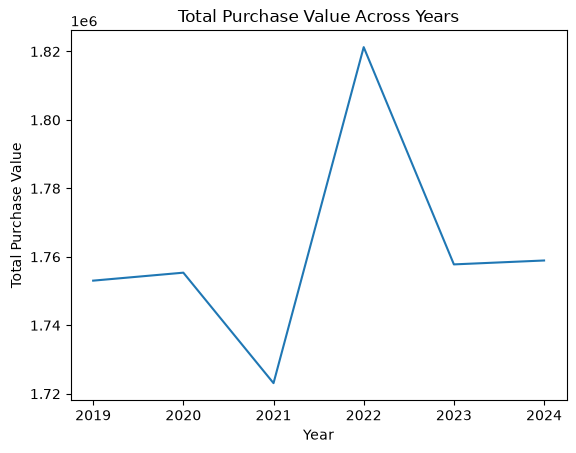

In [108]:
## Line Graph of Total Purchase Value by Year
plt.plot(purchase_by_year.index, purchase_by_year.values)
plt.xlabel('Year')
plt.ylabel('Total Purchase Value')
plt.title('Total Purchase Value Across Years')
plt.show()

In [ ]:
transactions.groupby('year')['customer_id'].count()

Q10. Plot purchasing value across product categories.

In [111]:
purchase_by_Category = transactions.groupby('product_category')['purchase_value'].sum()
print(purchase_by_Category)

product_category
beauty         1218918.23
electronics    5020188.13
fashion         759966.11
home           2022597.38
sports         1210881.70
toys            336960.71
Name: purchase_value, dtype: float64


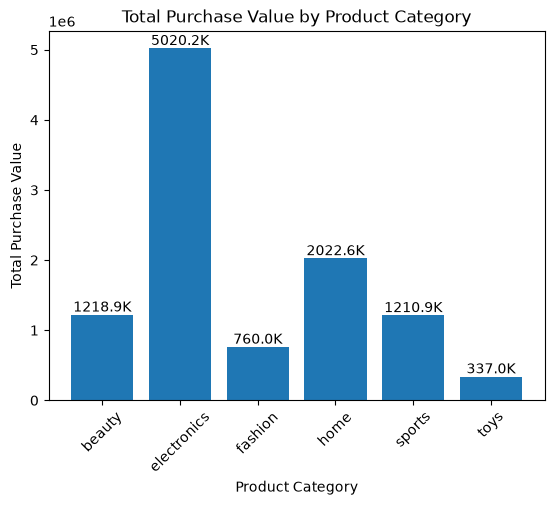

In [113]:
#Bar Graph of Total Purchase Value by Product Category
plt.bar(purchase_by_Category.index, purchase_by_Category.values)

for i, value in enumerate(purchase_by_Category.values):
    plt.text(i, value, f'{value/1000:.1f}K',
             ha='center', va='bottom')

plt.xlabel('Product Category')
plt.ylabel('Total Purchase Value')
plt.title('Total Purchase Value by Product Category')
plt.xticks(rotation=45)
plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

### Free Excercise

### Barchat showing Sales by Country

In [268]:
Merged= customers[['customer_id', 'country']].merge(
    transactions[['customer_id', 'purchase_value', 'product_category']], 
    on='customer_id', how='inner' )

CountrySales= Merged.groupby(['country'])['purchase_value'].sum()




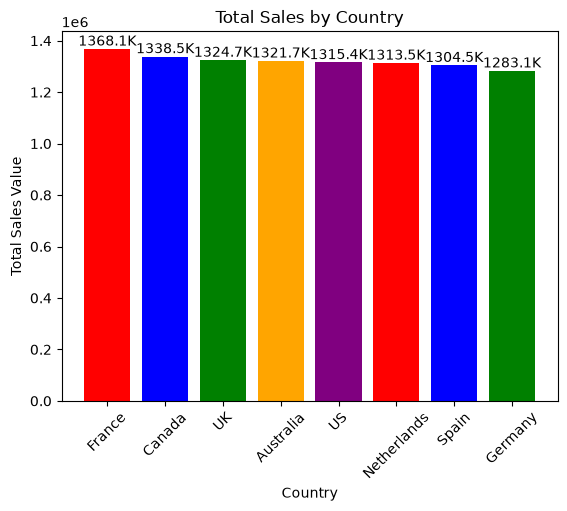

In [ ]:
#Plot Bar Graph of Total Sales by Country

country_sales = CountrySales.sort_values(ascending=False)
#creating bar plot set color
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.bar(country_sales.index, country_sales.values, color=colors)

for i, value in enumerate(country_sales.values):
    plt.text(i, value, f'{value/1000:.1f}K',
             ha='center', va='bottom')

plt.xlabel('Country')
plt.ylabel('Total Sales Value')
plt.title('Total Sales by Country')
plt.xticks(rotation=45)
plt.show()

### Bar Chart Showing the Highest Purchased Product in each Country

In [266]:
Merged= customers[['customer_id', 'gender', 'country']].merge(
    transactions[['customer_id', 'purchase_value', 'product_category']], 
    on='customer_id', how='inner' )
HighestsalesbyCategory= Merged.groupby(['product_category', 'country'])['purchase_value'].sum().sort_values(ascending=False)






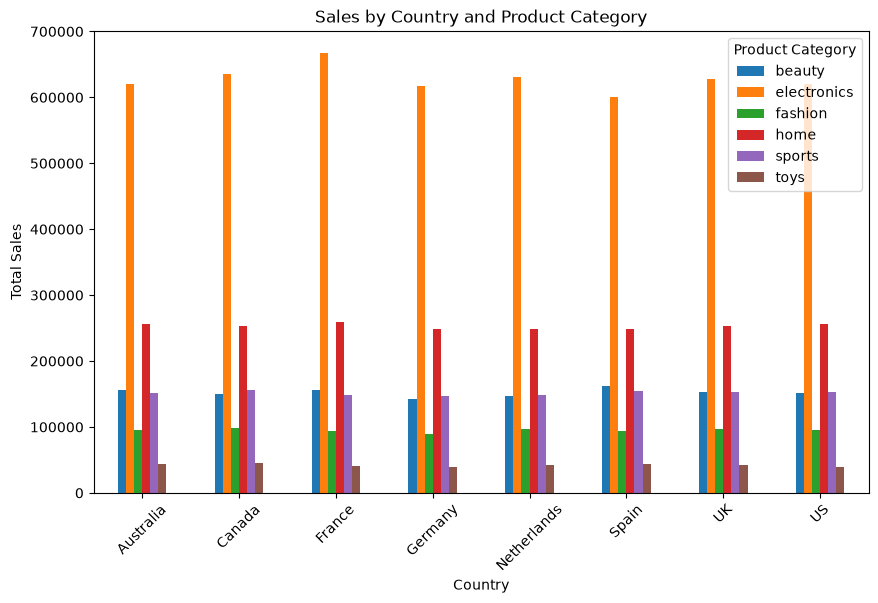

In [118]:
#barchart showing the highest sales by product category and country
plot_data = HighestsalesbyCategory.unstack(level='product_category')

plot_data.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.title('Sales by Country and Product Category')
plt.xticks(rotation=45)
plt.legend(title='Product Category')

plt.show()

#### Patterns and Relationships

##### Relationship Between Time spent on site, and Purchase Value

In [227]:
Merged= web_sessions[['customer_id', 'time_on_site', 'pages_viewed']].merge(
    transactions[['customer_id', 'purchase_value']], on='customer_id', how='inner' )

print(Merged.head(50))

np.corrcoef(Merged['time_on_site'], Merged['purchase_value'])[0, 1]

    customer_id  time_on_site  pages_viewed  purchase_value
0          9716    271.238207             8           72.55
1          9716    271.238207             8          154.15
2          9716    271.238207             8           39.44
3          9716    271.238207             8          181.60
4          9716    271.238207             8          349.48
5          9716    271.238207             8          153.03
6          9716    271.238207             8          164.62
7          9716    271.238207             8          496.07
8          9716    271.238207             8          161.42
9          9716    271.238207             8           93.79
10         9716    271.238207             8          173.08
11         9716    271.238207             8           56.84
12         9716    271.238207             8          279.95
13         4617    257.386842             5           69.28
14         4617    257.386842             5           66.68
15         4617    257.386842           

np.float64(0.00016377641820545486)

#### Relationship Between gender, product category, purchase value

In [274]:
Merged= customers[['customer_id','gender']].merge( 
    transactions[['customer_id', 'purchase_value', 'product_category']], 
    on='customer_id', how='inner' ) .sort_values(by='purchase_value', ascending=False)


print(Merged.head(10))

       customer_id  gender  purchase_value product_category
16921         3723    Male         1199.89      electronics
40938         9101  Female         1199.80      electronics
43997         9775   Other         1199.80      electronics
43743         9717  Female         1199.76      electronics
36552         8112    Male         1199.59      electronics
10831         2366   Other         1199.47      electronics
26543         5869   Other         1199.26      electronics
28363         6265  Female         1199.16      electronics
39948         8872  Female         1199.13      electronics
43612         9686  Female         1199.12      electronics


#### 2021 Decline Analysis

In [216]:
Merged = customers[['customer_id', 'country']].merge(
    transactions[['customer_id', 'purchase_date', 'product_category', 'purchase_value']],
    on='customer_id',
    how='inner'
).sort_values(by='purchase_value', ascending=False)

transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])
Merged['year'] = Merged['purchase_date'].dt.year

highest_purchase = Merged.groupby(
    ['country', 'product_category', 'year']
)['purchase_value'].sum()

print(highest_purchase)

country    product_category  year
Australia  beauty            2019    25632.15
                             2020    27339.39
                             2021    27363.04
                             2022    27473.98
                             2023    23699.59
                                       ...   
US         toys              2020     5880.09
                             2021     6969.02
                             2022     7267.06
                             2023     6834.51
                             2024     5896.68
Name: purchase_value, Length: 288, dtype: float64


#### Age Analysis

In [ ]:
#Age By Country and Customer ID
AVG_AGE= customers.groupby(['customer_id', 'country'])['age'].mean()

print(AVG_AGE)

np.mean(customers['age'].mean())

customer_id  country    
1            Germany        56.0
2            Netherlands    38.0
3            Australia      28.0
4            Australia      19.0
5            Australia      38.0
                            ... 
9996         US              NaN
9997         Spain          21.0
9998         US             50.0
9999         Netherlands    30.0
10000        Canada         40.0
Name: age, Length: 10000, dtype: float64


np.float64(43.5689111280322)

In [ ]:
#Age By Product Category
Average_Age = Merged.groupby('product_category')['age'].mean()

print(Average_Age)


##### 2020 Sales VS 2021



In [221]:
sales_2020_2021 = Merged[Merged['year'].isin([2020, 2021])]

country_year_sales = sales_2020_2021.groupby(
    ['country', 'year']
)['purchase_value'].sum().reset_index()

print(country_year_sales)

        country  year  purchase_value
0     Australia  2020       226652.84
1     Australia  2021       224327.57
2        Canada  2020       217873.87
3        Canada  2021       220958.71
4        France  2020       234301.14
5        France  2021       205087.35
6       Germany  2020       203033.19
7       Germany  2021       203028.73
8   Netherlands  2020       213285.18
9   Netherlands  2021       208550.35
10        Spain  2020       212934.22
11        Spain  2021       221490.92
12           UK  2020       220026.07
13           UK  2021       217446.93
14           US  2020       227267.31
15           US  2021       222206.18


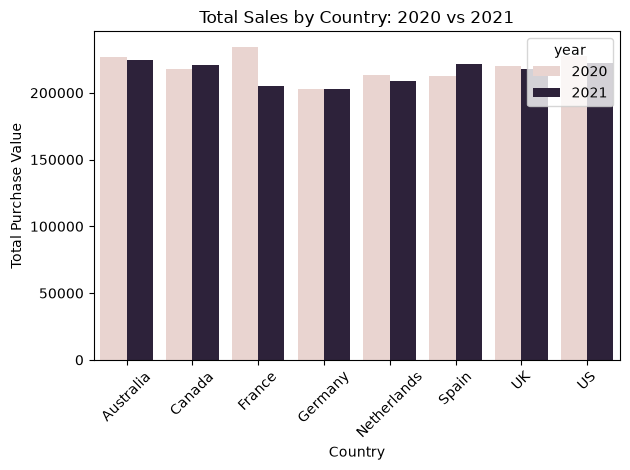

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=country_year_sales,
    x='country',
    y='purchase_value',
    hue='year'
)

plt.title('Total Sales by Country: 2020 vs 2021')
plt.xlabel('Country')
plt.ylabel('Total Purchase Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Product Category for 2020 vs 2021

In [224]:
Merged[
    Merged['year'].isin([2020, 2021])
].groupby(
    ['country', 'product_category', 'year']
)['purchase_value'].sum().reset_index()

,country,product_category,year,purchase_value
0,Australia,beauty,2020,27339.39
1,Australia,beauty,2021,27363.04
2,Australia,electronics,2020,107866.87
3,Australia,electronics,2021,110032.51
4,Australia,fashion,2020,15754.08
...,...,...,...,...
91,US,home,2021,43145.24
92,US,sports,2020,31065.00
93,US,sports,2021,23058.36
94,US,toys,2020,5880.09


Analyzing Highest sales country by Product (Count, sum, mean)

In [202]:
France = Merged[Merged['country'] == 'France']

France.groupby(
    ['year', 'product_category']
)['purchase_value'].sum()

year  product_category
2019  beauty               27710.65
      electronics         102950.41
      fashion              14823.62
      home                 45588.85
      sports               29795.41
      toys                  6555.80
2020  beauty               27405.47
      electronics         116279.69
      fashion              15921.51
      home                 42513.32
      sports               25676.35
      toys                  6504.80
2021  beauty               25408.44
      electronics         100782.58
      fashion              13899.19
      home                 37330.52
      sports               20757.06
      toys                  6909.56
2022  beauty               24130.13
      electronics         112655.64
      fashion              17609.90
      home                 52805.40
      sports               22655.04
      toys                  6995.80
2023  beauty               21975.63
      electronics         123044.16
      fashion              15969.96
     

In [203]:
France = Merged[Merged['country'] == 'France']

France.groupby(
    ['year', 'product_category']
)['purchase_value'].count()

year  product_category
2019  beauty              167
      electronics         153
      fashion             153
      home                159
      sports              183
      toys                147
2020  beauty              163
      electronics         166
      fashion             163
      home                165
      sports              165
      toys                149
2021  beauty              154
      electronics         155
      fashion             150
      home                145
      sports              131
      toys                157
2022  beauty              153
      electronics         164
      fashion             177
      home                190
      sports              161
      toys                162
2023  beauty              134
      electronics         183
      fashion             164
      home                137
      sports              163
      toys                153
2024  beauty              191
      electronics         173
      fashion    

In [207]:
France_AVG = Merged[Merged['country'] == 'France']

France.groupby(
    ['year', 'product_category']
)['purchase_value'].mean()

year  product_category
2019  beauty              165.932036
      electronics         672.878497
      fashion              96.886405
      home                286.722327
      sports              162.816448
      toys                 44.597279
2020  beauty              168.131718
      electronics         700.480060
      fashion              97.677975
      home                257.656485
      sports              155.614242
      toys                 43.656376
2021  beauty              164.989870
      electronics         650.210194
      fashion              92.661267
      home                257.451862
      sports              158.450840
      toys                 44.009936
2022  beauty              157.713268
      electronics         686.924634
      fashion              99.490960
      home                277.923158
      sports              140.714534
      toys                 43.183951
2023  beauty              163.997239
      electronics         672.372459
      fashion  

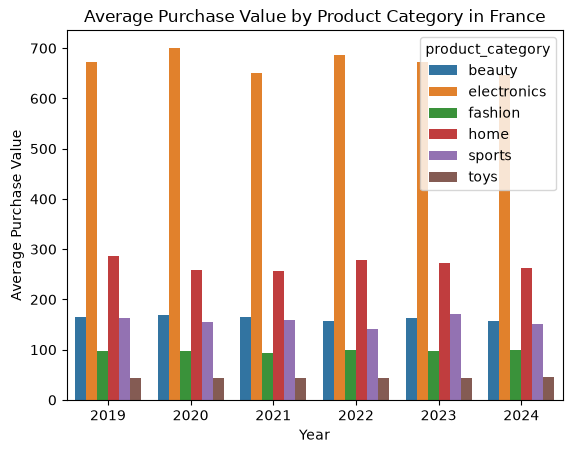

In [210]:
France_AVG = France.groupby(
    ['year', 'product_category']
)['purchase_value'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=France_AVG,
    x='year',
    y='purchase_value',
    hue='product_category'
)

plt.title('Average Purchase Value by Product Category in France')
plt.xlabel('Year')
plt.ylabel('Average Purchase Value')
plt.show()

#### Customer Acquistion Analysis

In [253]:
customers[['acquisition_channel']].value_counts()

acquisition_channel
paid_search            1953
email                  1938
social                 1911
referral               1896
organic                1824
Email                   282
paid_Search             196
Name: count, dtype: int64

Acquisition by conversion

In [265]:
Avg_PG = web_sessions[
    ['customer_id', 'converted', 'pages_viewed']
].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id',
    how='inner'
).merge(
    customers[['customer_id', 'acquisition_channel']],
    on='customer_id',
    how='inner'
).sort_values(by='acquisition_channel', ascending=False)

Converted_pageViews = Avg_PG[Avg_PG['converted'] == 1]

print(Converted_pageViews.head(50))

Converted_pageViews.groupby('acquisition_channel')['purchase_value'].mean()

        customer_id  converted  pages_viewed  purchase_value  \
100015         7383          1            10          153.50   
100014         7383          1            10          149.00   
100013         7383          1            10          783.83   
100012         7383          1            10           67.05   
99968           677          1             3           63.50   
99967           677          1             3          468.94   
99966           677          1             3          195.75   
99965           677          1             3          834.86   
99964           677          1             3          198.52   
99963           677          1             3          137.30   
100413         3412          1             6          128.96   
100412         3412          1             6           43.83   
100411         3412          1             6          111.28   
262847         7222          1             5          205.88   
262884         8288          1          

acquisition_channel
Email          234.090842
email          237.297772
organic        228.696845
paid_Search    216.732751
paid_search    234.845903
referral       240.395660
social         232.160702
Name: purchase_value, dtype: float64

### INSIGHTS

**1**. 
##### Website Engagement

***Analysis***:
I analyzed the relationship between time spent on site and purchase value using correlation, and compared the average time spent by converted and non-converted users.

***Insight***:
There is almost no correlation between time spent on site and purchase value (r = 0.00016). However, converted users spent slightly more time on the site on average (301.05 seconds) than non-converted users (294.96 seconds), a difference of 6.09 seconds.

***Recommendation***: The business should focus on improving the customer journey by making the website easier to navigate, helping customers find products more easily, and simplifying the path to purchase. This can help customers complete their purchases efficiently rather than requiring them to spend more time on the website.

**2**

##### Relationship Between Product Sales & Customer Age Analysis

**Analysis**
I analyzed purchase value by product category, calculated the overall average customer age, and compared average age across product categories.
* **Electronics** is the highest-selling product category.
* **Toys** is the lowest-selling product category.
* Overall average customer age is **43 years**.
* Average age across categories is very similar (**43.19–43.68 years**).

**Insight**
Despite the difference in sales, customer age is almost identical across categories, suggesting **age is not a major driver of product performance**.

**Recommendation**
The business should investigate other factors such as pricing, demand, availability, and customer preferences to better understand the difference in sales. It could also explore different age groups to identify opportunities for more targeted marketing.

**3**
#### Sales Analysis

**Analysis**
I calculated total sales by year, country, and product category to identify the main drivers of sales performance.

Insights

2022 recorded the highest total sales across the years analyzed.
France made a significant contribution to overall sales, driven largely by strong electronics sales.
Electronics has a significantly higher total purchase value than other product categories, which may be influenced by higher purchase values per transaction

Recommendation

The business could prioritize electronics in high-performing markets such as France and explore opportunities to strengthen other product categories. However, the available data was not sufficient to determine whether the higher sales were driven by transaction volume or higher purchase values per transaction, so this could be investigated further.

**4**

2021 Sales Decline

Analysis

I compared sales across years and countries to identify the factors contributing to the decline in 2021.

Insight

Sales declined in 2021, largely due to a decrease in sales from France. However, sales recovered in 2022, suggesting that the decline was not permanent. The strong impact of France on overall sales also indicates that a decline in one major market can significantly affect overall business performance.

Recommendation

The business should consider reducing its reliance on a single high-performing market by strengthening sales across other countries and product categories. This could help reduce the impact of future declines in France or other key markets.

***5***

Customer acquisition Channel Analysis

Analysis:

I analyzed the acquisition channels by comparing their conversion rates to identify which channels generated the highest proportion of converted customers.

**Insights**

Social Media recorded the highest conversion rate among the acquisition channels analyzed.
Making Social Media the most effective acquisition channel for converting visitors into customers.

Recommendation:

The business could consider increasing its focus on Social Media as an acquisition channel, given its stronger conversion performance.